<a href="https://colab.research.google.com/github/yasiruKodikara/FastAPI-python/blob/main/model_deployment_tutorial_insurence_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd

# Construct the raw GitHub URL for the CSV file
csv_url = "https://raw.githubusercontent.com/campusx-official/fastapi-demo-api/main/insurance.csv"

# Read the CSV into a pandas DataFrame
df = pd.read_csv(csv_url)

# Display the first few rows of the DataFrame
print(df.head())

   age  weight  height  income_lpa  smoker     city  occupation  \
0   67   119.8    1.56        2.92   False   Jaipur     retired   
1   36   101.1    1.83       34.28   False  Chennai  freelancer   
2   39    56.8    1.64       36.64   False   Indore  freelancer   
3   22   109.4    1.55        3.34    True   Mumbai     student   
4   69    62.2    1.60        3.94    True   Indore     retired   

  insurance_premium_category  
0                       High  
1                        Low  
2                        Low  
3                     Medium  
4                       High  


In [43]:
df.shape

(100, 8)

In [44]:
import numpy as np

In [66]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

#we gonna do feature engineering
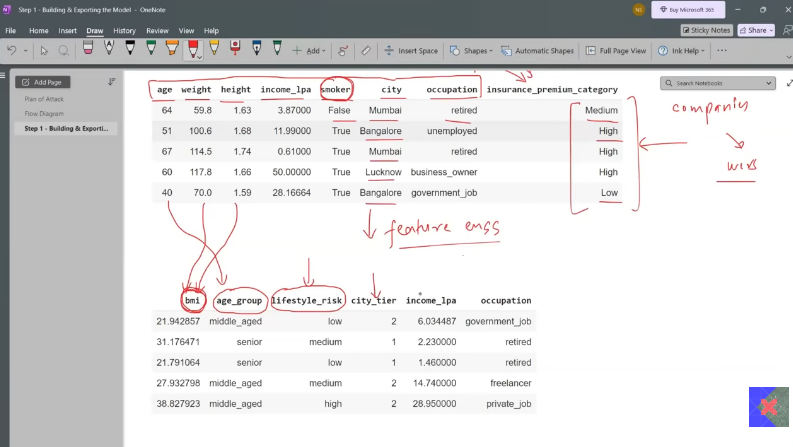

In [46]:
df['occupation'].unique()

array(['retired', 'freelancer', 'student', 'government_job',
       'business_owner', 'unemployed', 'private_job'], dtype=object)

In [47]:
df_feat = df.copy()

In [48]:
#Feature_1: BMI
df_feat["bmi"] = df_feat["weight"]/(df_feat["height"]**2)

In [49]:
df_feat.shape

(100, 9)

In [50]:
df_feat.head()

,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category,bmi
0,67,119.8,1.56,2.92,False,Jaipur,retired,High,49.227482
1,36,101.1,1.83,34.28,False,Chennai,freelancer,Low,30.189017
2,39,56.8,1.64,36.64,False,Indore,freelancer,Low,21.118382
3,22,109.4,1.55,3.34,True,Mumbai,student,Medium,45.535900
4,69,62.2,1.60,3.94,True,Indore,retired,High,24.296875


In [51]:
#Feature - 2 : age_group
def age_group(age):
  if age<25:
    return 'young'
  elif age < 45:
        return "adult"
  elif age < 60:
      return "middle_aged"
  return "senior"


In [52]:
df_feat["age_group"] = df_feat["age"].apply(age_group)

In [53]:
df_feat.head()

,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category,bmi,age_group
0,67,119.8,1.56,2.92,False,Jaipur,retired,High,49.227482,senior
1,36,101.1,1.83,34.28,False,Chennai,freelancer,Low,30.189017,adult
2,39,56.8,1.64,36.64,False,Indore,freelancer,Low,21.118382,adult
3,22,109.4,1.55,3.34,True,Mumbai,student,Medium,45.535900,young
4,69,62.2,1.60,3.94,True,Indore,retired,High,24.296875,senior


In [54]:
#Feature 3: lifestyle risk
def lifestyle_risk(row):
    if row["smoker"] and row["bmi"] > 30:
        return "high"
    elif row["smoker"] or row["bmi"] > 27:
        return "medium"
    else:
        return "low"

In [55]:
df_feat["lifestyle_risk"] = df_feat.apply(lifestyle_risk,axis=1)

In [56]:
tier_1_cities = ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata", "Hyderabad", "Pune"]
tier_2_cities = [
    "Jaipur", "Chandigarh", "Indore", "Lucknow", "Patna", "Ranchi", "Visakhapatnam", "Coimbatore",
    "Bhopal", "Nagpur", "Vadodara", "Surat", "Rajkot", "Jodhpur", "Raipur", "Amritsar", "Varanasi",
    "Agra", "Dehradun", "Mysore", "Jabalpur", "Guwahati", "Thiruvananthapuram", "Ludhiana", "Nashik",
    "Allahabad", "Udaipur", "Aurangabad", "Hubli", "Belgaum", "Salem", "Vijayawada", "Tiruchirappalli",
    "Bhavnagar", "Gwalior", "Dhanbad", "Bareilly", "Aligarh", "Gaya", "Kozhikode", "Warangal",
    "Kolhapur", "Bilaspur", "Jalandhar", "Noida", "Guntur", "Asansol", "Siliguri"
]

In [57]:
# Feature 4: City Tier
def city_tier(city):
    if city in tier_1_cities:
        return 1
    elif city in tier_2_cities:
        return 2
    else:
        return 3

In [58]:

df_feat["city_tier"] = df_feat["city"].apply(city_tier)

In [59]:
df_feat.drop(columns=['age', 'weight', 'height', 'smoker', 'city'])[['income_lpa', 'occupation', 'bmi', 'age_group', 'lifestyle_risk', 'city_tier', 'insurance_premium_category']].sample(5)


,income_lpa,occupation,bmi,age_group,lifestyle_risk,city_tier,insurance_premium_category
90,21.070000,business_owner,21.093750,middle_aged,low,1,Low
68,0.680000,student,22.963196,young,low,2,Low
55,24.930000,unemployed,25.293194,middle_aged,low,1,Low
14,13.505166,government_job,32.800735,middle_aged,medium,3,Medium
35,43.280000,private_job,20.762578,middle_aged,medium,2,Medium


In [60]:
X = df_feat[["bmi", "age_group", "lifestyle_risk", "city_tier", "income_lpa", "occupation"]]
y = df_feat["insurance_premium_category"]

In [61]:
X

,bmi,age_group,lifestyle_risk,city_tier,income_lpa,occupation
0,49.227482,senior,medium,2,2.92000,retired
1,30.189017,adult,medium,1,34.28000,freelancer
2,21.118382,adult,low,2,36.64000,freelancer
3,45.535900,young,high,1,3.34000,student
4,24.296875,senior,medium,2,3.94000,retired
...,...,...,...,...,...,...
95,21.420747,adult,low,2,19.64000,business_owner
96,47.984483,adult,medium,1,34.01000,private_job
97,18.765432,middle_aged,low,1,44.86000,freelancer
98,30.521676,adult,medium,1,28.30000,business_owner


In [62]:
y

,insurance_premium_category
0,High
1,Low
2,Low
3,Medium
4,High
...,...
95,Low
96,Low
97,Low
98,Low


In [63]:
# Define categorical and numeric features
categorical_features = ["age_group", "lifestyle_risk", "occupation", "city_tier"]
numeric_features = ["bmi", "income_lpa"]

In [64]:

# Create column transformer for OHE
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [67]:
# Create a pipeline with preprocessing and random forest classifier
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [68]:
# Split data and train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['age_group',
                                                   'lifestyle_risk',
                                                   'occupation', 'city_tier']),
                                                 ('num', 'passthrough',
                                                  ['bmi', 'income_lpa'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [69]:
# Predict and evaluate
y_pred = pipeline.predict(X_test)
accuracy_score(y_test, y_pred)

0.9

In [70]:

X_test.sample(5)

,bmi,age_group,lifestyle_risk,city_tier,income_lpa,occupation
65,37.662982,middle_aged,high,2,38.07,unemployed
78,27.932798,middle_aged,medium,2,14.74,freelancer
17,31.176471,senior,medium,1,2.23,retired
52,47.344720,young,medium,2,2.96,student
92,18.319942,adult,medium,2,30.00,government_job


In [71]:
df_feat

,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category,bmi,age_group,lifestyle_risk,city_tier
0,67,119.8,1.56,2.92000,False,Jaipur,retired,High,49.227482,senior,medium,2
1,36,101.1,1.83,34.28000,False,Chennai,freelancer,Low,30.189017,adult,medium,1
2,39,56.8,1.64,36.64000,False,Indore,freelancer,Low,21.118382,adult,low,2
3,22,109.4,1.55,3.34000,True,Mumbai,student,Medium,45.535900,young,high,1
4,69,62.2,1.60,3.94000,True,Indore,retired,High,24.296875,senior,medium,2
...,...,...,...,...,...,...,...,...,...,...,...,...
95,36,52.8,1.57,19.64000,False,Indore,business_owner,Low,21.420747,adult,low,2
96,26,113.8,1.54,34.01000,False,Delhi,private_job,Low,47.984483,adult,medium,1
97,52,60.8,1.80,44.86000,False,Hyderabad,freelancer,Low,18.765432,middle_aged,low,1
98,27,101.1,1.82,28.30000,False,Kolkata,business_owner,Low,30.521676,adult,medium,1


In [72]:
X

,bmi,age_group,lifestyle_risk,city_tier,income_lpa,occupation
0,49.227482,senior,medium,2,2.92000,retired
1,30.189017,adult,medium,1,34.28000,freelancer
2,21.118382,adult,low,2,36.64000,freelancer
3,45.535900,young,high,1,3.34000,student
4,24.296875,senior,medium,2,3.94000,retired
...,...,...,...,...,...,...
95,21.420747,adult,low,2,19.64000,business_owner
96,47.984483,adult,medium,1,34.01000,private_job
97,18.765432,middle_aged,low,1,44.86000,freelancer
98,30.521676,adult,medium,1,28.30000,business_owner


In [73]:
import pickle

# Save the trained pipeline using pickle
pickle_model_path = "model.pkl"
with open(pickle_model_path, "wb") as f:
    pickle.dump(pipeline, f)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')